## Muhammad Fadhlan - 00000083094

### Required packages: numpy, matplotlib.pyplot, seaborn, pandas, scipy, scikit-learn
### Other tools: Python 3.9>=, Golang SDK v1.21.3 (https://go.dev/dl/go1.21.3.windows-amd64.msi) or (https://go.dev/dl/go1.21.3.linux-amd64.tar.gz) or (https://go.dev/dl/go1.21.3.darwin-amd64.pkg) or (https://go.dev/dl/go1.21.3.darwin-arm64.pkg)

In [1]:
# imports

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [10]:
# Load data
data = pd.read_csv('IDX 2000-2024.csv')

In [ ]:
# Display the first 5 rows of the data
data.head()

In [13]:
!cd ./cachegenerator && go build && cp bigdata ../bigdata
!chmod +x ./bigdata
!./bigdata -input="IDX 2000-2024.csv" -outputsuffix="raw"

Processing data for years:  [2014 2015 2018 2021 2023 2011 2017 2020 2001 2002 2004 2006 2009 2022 2000 1 2003 2007 2019 2024 2016 2005 2008 2010 2012 2013]
Preparing data for year 2022...
Processing data for year 2022...
Preparing data for year 2007...
Processing data for year 2007...
Preparing data for year 2013...
Processing data for year 2013...
Preparing data for year 2000...
Processing data for year 2000...
Preparing data for year 2006...
Processing data for year 2006...
Preparing data for year 2011...
Processing data for year 2011...
Preparing data for year 2009...
Processing data for year 2009...
Preparing data for year 2004...
Processing data for year 2004...
Preparing data for year 2003...
Processing data for year 2003...
Preparing data for year 2008...
Processing data for year 2008...
Preparing data for year 1...
Processing data for year 1...
Preparing data for year 2012...
Processing data for year 2012...
Data for year 2007 processed
Data for year 2000 processed
Data for ye

In [12]:
!cd ./cachegenerator && go build && copy bigdata.exe ../bigdata.exe
!bigdata.exe -input="IDX 2000-2024.csv" -outputsuffix="raw"

/bin/bash: line 1: copy: command not found
/bin/bash: line 1: bigdata.exe: command not found


In [43]:
# Read from already computed cache
peryearclose = pd.read_json('peryearcloseraw.json')
peryearopen = pd.read_json('peryearopenraw.json')
peryearvolume = pd.read_json('peryearvolumeraw.json')

alltimeclose = pd.read_json('alltimecloseraw.json')
alltimeopen = pd.read_json('alltimeopenraw.json')
alltimevolume = pd.read_json('alltimevolumeraw.json')
periods = pd.read_json('periodsraw.json')

In [14]:
# ATTENTION: AS THE LECTURER, YOU SHOULD NOT RUN THIS CELL, AS IT TAKES A LONG TIME TO EXECUTE, SAVE YOURSELF THE TIME, AND USE THE CELL ABOVE TO LOAD THE PRECOMPUTED DATA
# AND USE THE CELL 2 CELLS ABOVE THIS ONE TO BUILD THE APP AND GENERATE THE CACHE
# THIS CELL IS ONLY FOR DEMONSTRATION PURPOSES, NOT FOR EXEC
# Averages for all companies (histogram)
companies = data['Ticker'].unique()
parseddate = pd.to_datetime(data['Date'])
data['Date'] = parseddate
years = parseddate.dt.year.unique()
peryearclose = {}
peryearopen = {}
peryearvolume = {}

for year in years:
    peryearclose[year] = []
    peryearopen[year] = []
    peryearvolume[year] = []
    for company in companies:
        fetch = data[(data["Ticker"] == company) & (data["Date"].dt.year == year)]
        peryearclose[year].append(fetch["Close"].mean())
        peryearopen[year].append(fetch["Open"].mean())
        peryearvolume[year].append(fetch["Volume"].mean())

pd.DataFrame(peryearclose).to_json('peryearclose.json')
pd.DataFrame(peryearopen).to_json('peryearopen.json')
pd.DataFrame(peryearvolume).to_json('peryearvolume.json')


In [ ]:
# ATTENTION: AS THE LECTURER, YOU SHOULD NOT RUN THIS CELL, AS IT TAKES A LONG TIME TO EXECUTE, SAVE YOURSELF THE TIME, AND USE THE CELL 2 CELLS ABOVE THIS ONE TO LOAD THE PRECOMPUTED DATA
# AND USE THE CELL 3 CELLS ABOVE THIS ONE TO BUILD THE APP AND GENERATE THE CACHE
# THIS CELL IS ONLY FOR DEMONSTRATION PURPOSES, NOT FOR EXEC
# Averages for all companies (line chart)
companies = data['Ticker'].unique()
parseddate = pd.to_datetime(data['Date'])
data['Date'] = parseddate
years = parseddate.dt.year.unique()
alltimeclose = []
alltimeopen = []
alltimevolume = []

lowestperiod = data['Date'].min()
highestperiod = data['Date'].max()
currentperiod = lowestperiod
periods = []
while currentperiod <= highestperiod:
    fetch = data[data["Date"] == currentperiod]
    alltimeclose.append(fetch["Close"].mean())
    alltimeopen.append(fetch["Open"].mean())
    alltimevolume.append(fetch["Volume"].mean())
    periods.append(currentperiod)
    currentperiod = currentperiod + pd.DateOffset(1)

pd.DataFrame(alltimeclose).to_json('alltimeclose.json')
pd.DataFrame(alltimeopen).to_json('alltimeopen.json')
pd.DataFrame(alltimevolume).to_json('alltimevolume.json')
pd.DataFrame(periods).to_json('periods.json')


In [10]:
#Average for all companies (bar chart)
companies = data['Ticker'].unique()
parseddate = pd.to_datetime(data['Date'])
data['Date'] = parseddate
years = parseddate.dt.year.unique()
closeperyear = []
openperyear = []
volumeperyear = []

for year in years:
    fetch = data[data["Date"].dt.year == year]
    closeperyear.append(fetch["Close"].mean())
    openperyear.append(fetch["Open"].mean())
    volumeperyear.append(fetch["Volume"].mean())

# This is fast enough that caching is not necessary

In [ ]:
# Histograms

parseddate = pd.to_datetime(data['Date'])
data['DateP'] = parseddate
years = parseddate.dt.year.unique()

for year in years:
    plt.figure(figsize=(10, 5))
    sns.histplot(peryearopen[year][peryearopen[year] < 2500], kde=True, bins=25)
    plt.title(f'Open price distribution for year {year}')
    plt.show()



In [ ]:
# Line chart
plt.figure(figsize=(10, 5))
df = pd.DataFrame({
    'Period': periods[0],
    'Opening Price': alltimeopen[0],
    'Closing Price': alltimeclose[0],
    'Volume': alltimevolume[0]
})
filtered = df[(df['Period'] > '2005-01-01') & (df["Opening Price"] > 0)]

plt.plot(filtered['Period'], filtered['Opening Price'], label='Opening Price')
plt.title('Average Opening Across All Companies over time')
positions = filtered['Period'][::85]  # Show every 10th label
labels = filtered['Period'][::85]
plt.xticks(ticks=positions, labels=labels, rotation=90)  # Rotate for better readability
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(filtered['Period'], filtered['Closing Price'], label='Closing Price')
plt.title('Average Closing Across All Companies over time')
positions = filtered['Period'][::85]  # Show every 10th label
labels = filtered['Period'][::85]
plt.xticks(ticks=positions, labels=labels, rotation=90)  # Rotate for better readability
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(filtered['Period'], filtered['Volume'], label='Volume')
plt.title('Average Volume Across All Companies over time')
positions = filtered['Period'][::85]  # Show every 10th label
labels = filtered['Period'][::85]
plt.xticks(ticks=positions, labels=labels, rotation=90)  # Rotate for better readability
plt.show()



In [ ]:
# Bar charts
plt.figure(figsize=(10, 5))
plt.bar(years, openperyear)
plt.title('Average Opening Price per Year')
plt.show()
plt.figure(figsize=(10, 5))
plt.bar(years, closeperyear)
plt.title('Average Closing Price per Year')
plt.show()
plt.figure(figsize=(10, 5))
plt.bar(years, volumeperyear)
plt.title('Average Volume per Year')
plt.show()

In [ ]:
# Filter dataset using Z-score
from scipy import stats

clean = data.dropna()
reduced = clean[['Open', 'Close', 'Volume', "Date"]]
z = stats.zscore(reduced[['Open', 'Close', 'Volume']])

filtered = reduced[(np.abs(z) < 3).all(axis=1)]
filtered

volumeperyear = []

for year in years:
    fetch = filtered[filtered["Date"].dt.year == year]
    volumeperyear.append(fetch["Volume"].mean())

plt.figure(figsize=(10, 5))
plt.bar(years, volumeperyear)
plt.title('Average Volume per Year')
plt.show()

In [51]:
# Bin companies by their average volume
bins = pd.cut(filtered['Volume'],5)
filtered['VolumeBin'] = bins
filtered


C:\Users\muham\AppData\Local\Temp\ipykernel_3476\2726470584.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['VolumeBin'] = bins


,Open,Close,Volume,Date,VolumeBin
0,571.710632,547.889343,57721.0,2001-04-05,"(-369132.141, 73826428.2]"
1,547.889343,547.889343,83433.0,2001-04-06,"(-369132.141, 73826428.2]"
2,547.889343,547.889343,10494.0,2001-04-09,"(-369132.141, 73826428.2]"
3,547.889343,547.889343,352625.0,2001-04-10,"(-369132.141, 73826428.2]"
4,547.889343,547.889343,59295.0,2001-04-11,"(-369132.141, 73826428.2]"
...,...,...,...,...,...
2622882,149.000000,146.000000,180100.0,2024-05-13,"(-369132.141, 73826428.2]"
2622883,146.000000,146.000000,95800.0,2024-05-14,"(-369132.141, 73826428.2]"
2622884,143.000000,140.000000,3749200.0,2024-05-15,"(-369132.141, 73826428.2]"
2622885,141.000000,139.000000,437800.0,2024-05-16,"(-369132.141, 73826428.2]"


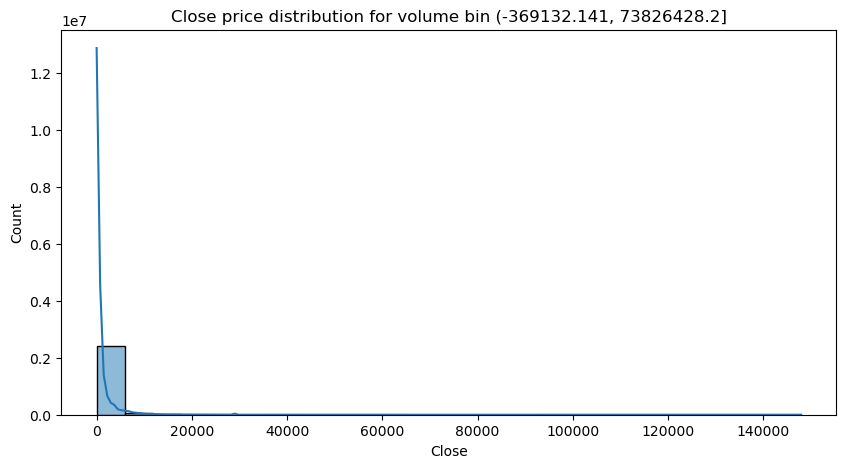

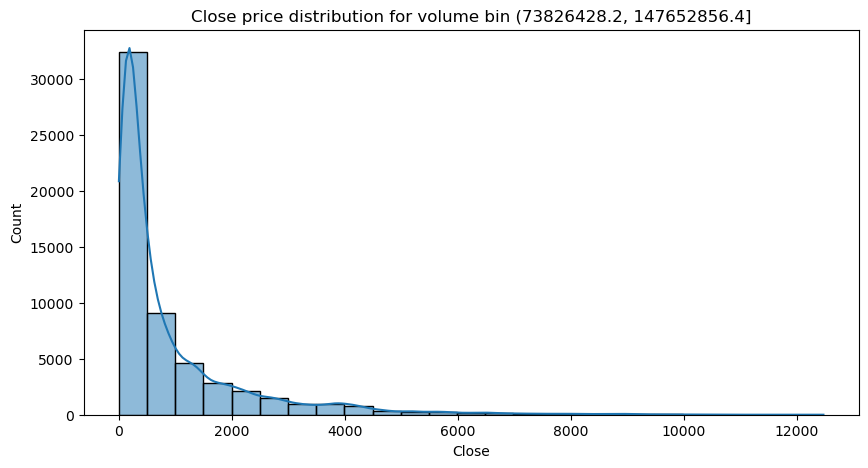

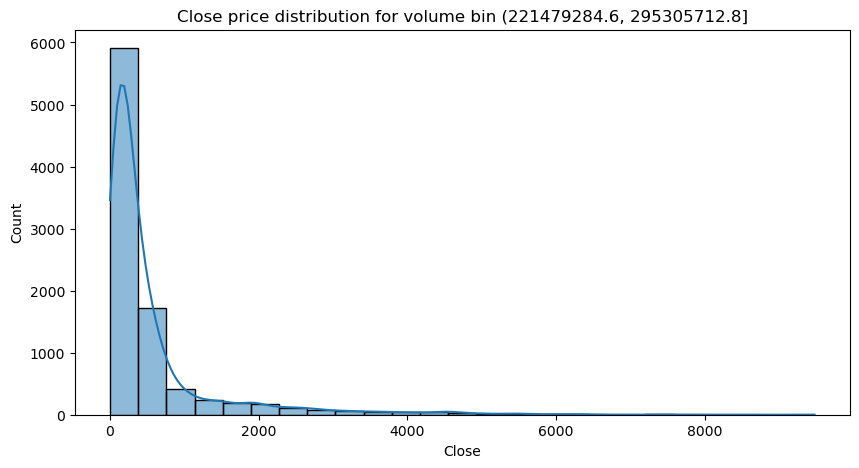

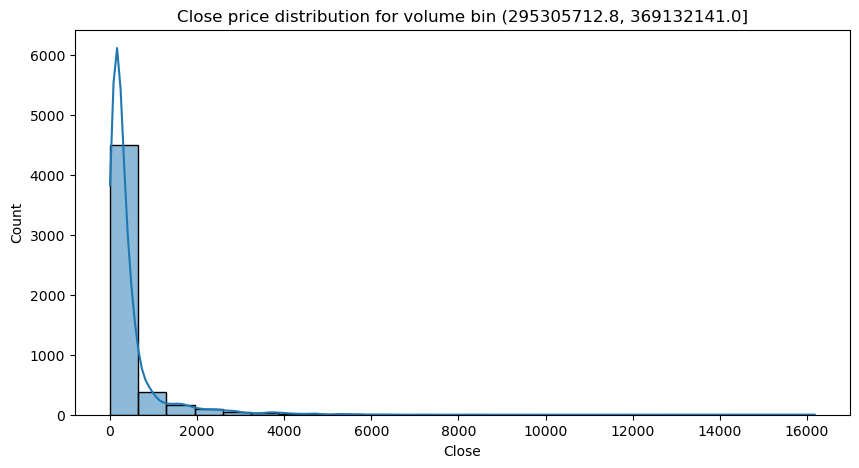

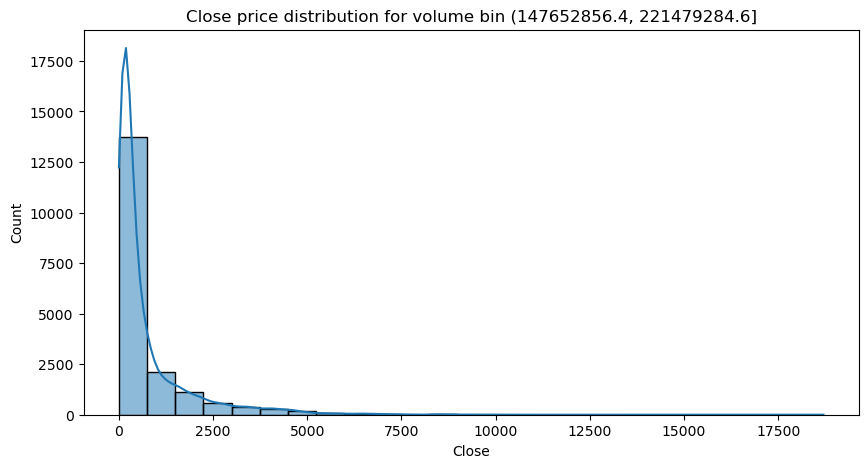

In [52]:
bins.unique()

# Plot average closing price for each bin
bins = filtered['VolumeBin'].unique()
for bin in bins:
    fetch = filtered[filtered["VolumeBin"] == bin]
    plt.figure(figsize=(10, 5))
    sns.histplot(fetch["Close"], kde=True, bins=25)
    plt.title(f'Close price distribution for volume bin {bin}')
    plt.show()

In [54]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized = filtered.copy()
normalized[['Open', 'Close', 'Volume']] = scaler.fit_transform(normalized[['Open', 'Close', 'Volume']])
normalized

,Open,Close,Volume,Date,VolumeBin
0,0.003863,0.003702,0.000156,2001-04-05,"(-369132.141, 73826428.2]"
1,0.003702,0.003702,0.000226,2001-04-06,"(-369132.141, 73826428.2]"
2,0.003702,0.003702,0.000028,2001-04-09,"(-369132.141, 73826428.2]"
3,0.003702,0.003702,0.000955,2001-04-10,"(-369132.141, 73826428.2]"
4,0.003702,0.003702,0.000161,2001-04-11,"(-369132.141, 73826428.2]"
...,...,...,...,...,...
2622882,0.001007,0.000987,0.000488,2024-05-13,"(-369132.141, 73826428.2]"
2622883,0.000986,0.000987,0.000260,2024-05-14,"(-369132.141, 73826428.2]"
2622884,0.000966,0.000946,0.010157,2024-05-15,"(-369132.141, 73826428.2]"
2622885,0.000953,0.000939,0.001186,2024-05-16,"(-369132.141, 73826428.2]"
